### Logic Gate Network

**Imports**

In [7]:
import numpy as np
from scipy.special import softmax
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

**Logic operators**

In [8]:
def op_false(a, b): 
    return np.zeros_like(a)

def op_and(a, b): 
    return a * b

def op_not_imp_ab(a, b): 
    return a - a*b

def op_A(a, b): 
    return a

def op_not_imp_ba(a, b): 
    return b - a*b

def op_B(a, b): 
    return b

def op_xor(a, b): 
    return a + b - 2*a*b

def op_or(a, b): 
    return a + b - a*b

def op_not_or(a, b): 
    return 1 - (a + b - a*b)

def op_xnor(a, b): 
    return 1 - (a + b - 2*a*b)

def op_notB(a, b): 
    return 1 - b

def op_leqA(a, b): 
    return 1 - b + a*b

def op_notA(a, b): 
    return 1 - a

def op_implAB(a, b): 
    return 1 - a + a*b

def op_not_and(a, b): 
    return 1 - a*b

def op_true(a, b): 
    return np.ones_like(a)

def counted_operators(a, b):
    return np.stack([
        op_false(a,b),
        op_and(a, b),
        op_not_imp_ab(a, b),
        op_A(a, b),
        op_not_imp_ba(a, b),
        op_B(a, b),
        op_xor(a, b), 
        op_or(a, b),
        op_not_or(a, b), 
        op_xnor(a, b),
        op_notB(a, b),
        op_leqA(a, b), 
        op_notA(a, b),
        op_implAB(a, b),
        op_not_and(a, b),
        op_true(a, b),
    ], axis=0)

## Logic Net

**Single neuron**

- Losowo wybiera sobie DWA wejścia (np. bit A i bit B)
- Potem sprawdza wszystkie 16 możliwych operacji logicznych między tymi dwoma bitami
- Zamiast twardo wybrać jedną operację, „miękko” je miesza – każdej operacji daje jakieś prawdopodobieństwo (softmax)
- Na wyjściu daje coś pomiędzy 0 a 1 – średnią ważoną wszystkich 16 bramek logicznych

In [9]:
class LogicGateNeuron:
    def __init__(self, num_inputs):
        self.num_inputs = num_inputs

        self.input_a_idx = np.random.randint(num_inputs)
        self.input_b_idx = np.random.randint(num_inputs)

        self.operator_logits = np.random.randn(16) * 0.5

    def forward(self, X, temperature):
        a = X[..., self.input_a_idx]
        b = X[..., self.input_b_idx]

        operators = counted_operators(a, b)

        operator_prob = softmax(self.operator_logits / temperature)

        self._cache = (operators, operator_prob)

        return np.sum(operators * operator_prob[:, None], axis=0)

    def backward(self, grad_output, temperature):
        operators, operator_prob = self._cache

        expected_op = np.sum(operators * operator_prob[:, None], axis=0)

        diff = operators - expected_op[None, :]

        grad_logits = np.sum(diff * operator_prob[:, None] * grad_output[None, :], axis=1) / temperature
        return grad_logits


**One Layer**
- listy neuronów

In [10]:
class LogicGateLayer:
    def __init__(self, input_dim, output_dim):
        self.neurons = [LogicGateNeuron(input_dim) for _ in range(output_dim)]
        self.output_dim = output_dim
        self.input_dim = input_dim

    def forward(self, X, temperature):
        return np.stack([neuron.forward(X, temperature) for neuron in self.neurons], axis=-1)

    def backward(self, grad_output, temperature):
        return [neuron.backward(grad_output[:, i], temperature) for i, neuron in enumerate(self.neurons)]
    

**Network**
- warstwy + ostatnia wyjściowa
- wsteczna propagacja błędu
- progresywne zmniejszanie temperatury
- early stop jak mamy 100% acc


In [11]:
class LogicGatesNetwork:
    def __init__(self, input_bits, hidden_layers=[32], num_classes=2, ops_per_class=8, temperature=1.0):
        self.temperature = temperature
        self.num_classes = num_classes
        self.ops_per_class = ops_per_class

        self.layers = []
        current_dim = input_bits

        for layer_size in hidden_layers:
            self.layers.append(LogicGateLayer(current_dim, layer_size))
            current_dim = layer_size

        self.output_layer = LogicGateLayer(current_dim, num_classes * ops_per_class)

        self.all_layers = self.layers + [self.output_layer]

    def forward(self, X):
        activ = X.astype(np.float32)

        for layer in self.layers:
            activ = layer.forward(activ, self.temperature)

        activ = self.output_layer.forward(activ, self.temperature)

        scores = activ.reshape(-1, self.num_classes, self.ops_per_class).sum(axis=2)
        return scores

    def fit(self, X, y, epochs=5000, lr=1.0):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.int64)
        batch_size = X.shape[0]

        for ep in range(1, epochs + 1):
            scores = self.forward(X)

            exp_s = np.exp(scores - scores.max(axis=1, keepdims=True))
            probs = exp_s / exp_s.sum(axis=1, keepdims=True)

            grad_scores = probs.copy()
            grad_scores[np.arange(batch_size), y] -= 1
            grad_scores /= batch_size

            grad_out = np.zeros((batch_size, self.output_layer.output_dim))
            for cls in range(self.num_classes):
                start = cls * self.ops_per_class
                end = start + self.ops_per_class
                grad_out[:, start:end] = grad_scores[:, [cls]]

            for layer in self.all_layers:
                grads = layer.backward(grad_out, self.temperature)
                for neuron, g in zip(layer.neurons, grads):
                    neuron.operator_logits -= lr * np.clip(g, -1, 1)

            if ep % 500 == 0 or ep == 1:
                acc = accuracy_score(y, self.predict(X))
                print(f"{ep:4d} | Acc: {acc:.3f} | tau: {self.temperature:.3f}")

                if acc == 1.0:
                    print("BREAK | accuracy = 1")
                    return

            if ep % 1000 == 0 and self.temperature > 0.1:
                self.temperature *= 0.7

    def predict(self, X):
        return self.forward(np.asarray(X, dtype=np.float32)).argmax(axis=1)


### **Test**

   1 | Acc: 0.500 | tau: 1.500
 500 | Acc: 0.500 | tau: 1.500
1000 | Acc: 0.500 | tau: 1.500
1500 | Acc: 0.500 | tau: 1.050
2000 | Acc: 0.500 | tau: 1.050
2500 | Acc: 0.625 | tau: 0.735
3000 | Acc: 0.750 | tau: 0.735
3500 | Acc: 0.625 | tau: 0.514
4000 | Acc: 0.500 | tau: 0.514
4500 | Acc: 1.000 | tau: 0.360
BREAK | accuracy = 1
Predictions: [0 1 1 0 1 0 0 1]
True labels: [0 1 1 0 1 0 0 1]


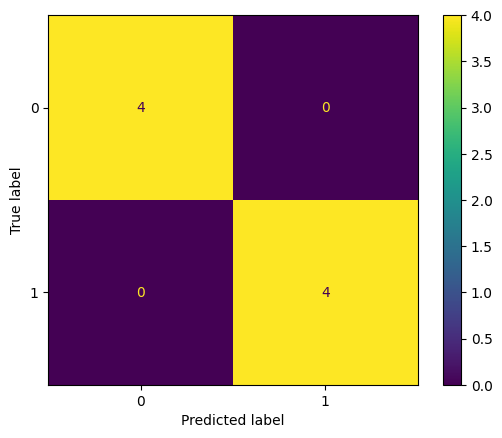

In [12]:
X = np.array([
    [0,0,0],
    [0,0,1],
    [0,1,0],
    [0,1,1],
    [1,0,0],
    [1,0,1],
    [1,1,0],
    [1,1,1]
], dtype=np.float32)

y = np.array([0,1,1,0,1,0,0,1]) 

model = LogicGatesNetwork(
    input_bits=3, 
    hidden_layers=[32, 32],
    ops_per_class=16,
    temperature=1.5
)
model.fit(X, y, epochs=5000, lr=1.0)
    
acc = accuracy_score(y, model.predict(X))

pred = model.predict(X)
print("Predictions:", pred)
print("True labels:", y)
ConfusionMatrixDisplay.from_predictions(y, pred)